<a href="https://colab.research.google.com/github/Teja-630/ENERGY_PREDICTION/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Dataset...
Dataset Loaded Successfully!

Dataset Preview:
        Date  Irradiance  Temperature  Power_Output
0 2024-01-01      749.82        25.78        107.95
1 2024-01-02      980.29        32.97        140.05
2 2024-01-03      892.80        33.11        133.09
3 2024-01-04      839.46        34.56        123.21
4 2024-01-05      662.41        35.89        105.43

Data Split Complete:
Training samples: 210
Testing samples: 90

Model Trained Successfully!

Model Evaluation Results:
Mean Absolute Error (MAE): 4.42
R² Score: 0.87

Sample Prediction Results:
          Date  Irradiance  Temperature  Power_Output  Predicted_Power
203 2024-07-22      959.42        37.21        144.78       143.451382
266 2024-09-23      878.81        30.88        131.70       130.008024
152 2024-06-01      657.96        31.36        100.18       104.736831
9   2024-01-10      883.23        29.06        130.31       129.339534
233 2024-08-21      797.01        33.33        120.43       122.121702


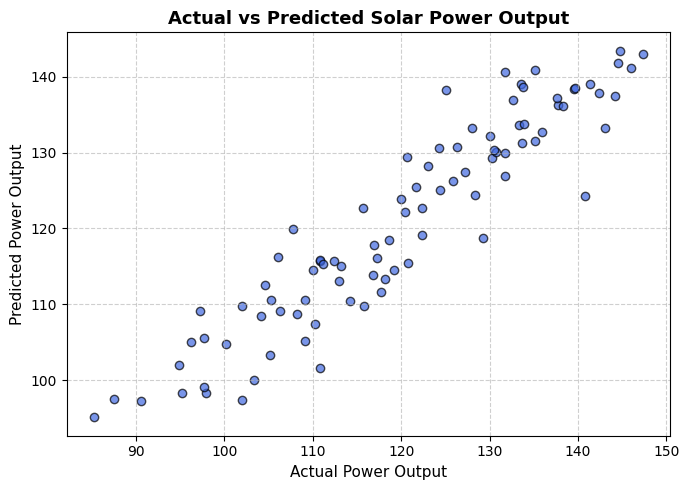

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("Loading Dataset...")
df = pd.read_csv('solar_dataset.csv', parse_dates=['Date'])
print("Dataset Loaded Successfully!\n")

print("Dataset Preview:")
print(df.head())

X = df[['Irradiance', 'Temperature']]
y = df['Power_Output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nData Split Complete:")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel Trained Successfully!")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

results = df.loc[y_test.index].copy()
results['Predicted_Power'] = y_pred

print("\nSample Prediction Results:")
print(results[['Date', 'Irradiance', 'Temperature', 'Power_Output', 'Predicted_Power']].head())

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='royalblue', edgecolor='black', alpha=0.7)
plt.xlabel("Actual Power Output", fontsize=11)
plt.ylabel("Predicted Power Output", fontsize=11)
plt.title("Actual vs Predicted Solar Power Output", fontsize=13, weight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()